In [1]:
import gtsam
import numpy as np
import matplotlib.pyplot as plt
from gtbook.display import show
from gtsam.symbol_shorthand import X, L
import gtsam.utils.plot as gtsam_plot
from utilities.utils import kstr
from data.data_generator_linear import SimulationConfig, RobotSimulatorR2, build_linear_factor_graph

### Create factor graph

In [2]:
# Create simulation configuration
config = SimulationConfig(
    poses=[
        np.array([0.0, 0.0]),  # X1
        np.array([2.0, 0.0]),  # X2
        np.array([4.0, 0.0])   # X3
    ],
    landmarks=[],
    observations={},
    prior_noise_sim=np.array([0, 0]),
    odometry_noise_sim=np.array([0.1, 0.1]),
    measurement_noise_sim=np.array([0.1, 0.1])
)

simulator = RobotSimulatorR2(config)
sim_data = simulator.simulate()

gfg = build_linear_factor_graph(
    sim_data,
    prior_noise_fg=np.array([0.05, 0.05]),
    odometry_noise_fg=np.array([0.1, 0.1]),  
    measurement_noise_fg=np.array([0.1, 0.1])
)

pose_vars = [X(i+1) for i in range(len(sim_data['ground_truth']['poses']))]
landmark_vars = [L(i+1) for i in range(len(sim_data['ground_truth']['landmarks']))]
all_vars = pose_vars + landmark_vars

### Optimization

In [13]:
solution = gfg.optimize()
print(f"solution = {solution} with error {gfg.error(solution)}")

# solution_dense = gfg.optimizeDensely()
# print(f"solution_dense = {solution_dense} with error {gfg.error(solution_dense)}")

solution = VectorValues: 3 elements
  x1: -7.94411e-17  4.96507e-18
  x2:   2.12938 0.0397977
  x3:   4.24124 -0.109427
 with error 1.114712844371777e-29


### Covariances

The $d$ below is the "square root information vector", as the Bayes net defines the following quadratic, and corresponding Gaussian density, in this case in $\mathbb{R}^6$:

$$
E_{gbn}(x; R, d) \doteq \frac{1}{2} \|Rx - d\|^2
$$

$$
\mathcal{N}_{gbn}(x; R, d) \sim k \exp \{- \frac{1}{2} \|Rx - d\|^2\}
$$

In [14]:
# Convert to Gaussian Bayes Net
gbn = gfg.eliminateSequential()
show(gbn)

R, d = gbn.matrix() # Suquare root information matrix (R) and vector (d)
information_matrix = R.T @ R
covariance_matrix = np.linalg.inv(R.T @ R) 

#### Covariance Computation Methods in GTSAM

There are two common ways to obtain covariance matrices from a factor graph:

1. **From the Hessian (Information Form)**  
   - The factor graph can be expressed in canonical Gaussian form  
     $
     E(x) = \tfrac{1}{2} x^\top \Lambda x - x^\top \eta + \text{const},
     $  
     where $\Lambda = P^{-1}$ is the **information matrix**.  
   - Calling `gfg.hessian()` constructs this global information matrix \(\Lambda\).  
   - Inverting it yields the full covariance:  
     $
     P_{\text{information}} = \Lambda^{-1}.
     $  
   - Marginal covariances of subsets of variables can then be obtained by slicing the corresponding blocks of $P_{\text{information}}$.  
   - **Advantage:** straightforward, gives full covariance.  
   - **Disadvantage:** requires inverting the entire information matrix (expensive for large problems).  

2. **From Marginalization (Elimination-Based)**  
   - The `Marginals` class computes covariances by **eliminating variables** in the factor graph (e.g., via Cholesky factorization).  
   - This allows extracting only the covariance for a subset of variables without forming the entire $P$.  
   - Calling `marginals.marginalCovariance(key)` gives the covariance for one variable.  
   - Calling `marginals.jointMarginalCovariance(keys)` gives the joint covariance matrix for a set of variables.  
   - **Advantage:** efficient for subsets; avoids computing the full inverse.  
   - **Disadvantage:** requires repeated queries if many different marginals are needed.  

---

**Key Point:** Both methods give the *same result mathematically*. The difference is purely in **how the computation is carried out**:  
- **Hessian inversion:** global, dense, expensive.  
- **Marginals API:** local, on-demand, efficient.  


In [15]:
# Marginals object
marginals = gtsam.Marginals(gfg, solution)

# Compute global covariance from Hessian
information_matrix, _ = gfg.hessian()
P_information = np.linalg.inv(information_matrix)
joint = marginals.jointMarginalCovariance(pose_vars)
joint_cov = joint.fullMatrix()

### Comparing covariances

In [16]:
# Compare individual pose covariances
for i, key in enumerate(pose_vars, start=1):
    cov_from_joint = joint.at(key, key)
    cov_from_marg = marginals.marginalCovariance(key)

    print(f"{kstr(key)}:")
    print("From full joint cov matrix:\n", cov_from_joint)
    print("From marginals:\n", cov_from_marg)
    print("Equal? ->", np.allclose(cov_from_joint, cov_from_marg, atol=1e-10))
    print("-"*50) 

# Compare joint covariance (all poses together)
joint_cov = marginals.jointMarginalCovariance(pose_vars).fullMatrix()
print("Joint covariance (marginals) vs. full inverse match? ->",
      np.allclose(joint_cov, P_information, atol=1e-8))
# np.set_printoptions(precision=3, suppress=True)

X1:
From full joint cov matrix:
 [[0.0025 0.    ]
 [0.     0.0025]]
From marginals:
 [[0.0025 0.    ]
 [0.     0.0025]]
Equal? -> True
--------------------------------------------------
X2:
From full joint cov matrix:
 [[0.0125 0.    ]
 [0.     0.0125]]
From marginals:
 [[0.0125 0.    ]
 [0.     0.0125]]
Equal? -> True
--------------------------------------------------
X3:
From full joint cov matrix:
 [[0.0225 0.    ]
 [0.     0.0225]]
From marginals:
 [[0.0225 0.    ]
 [0.     0.0225]]
Equal? -> True
--------------------------------------------------
Joint covariance (marginals) vs. full inverse match? -> True


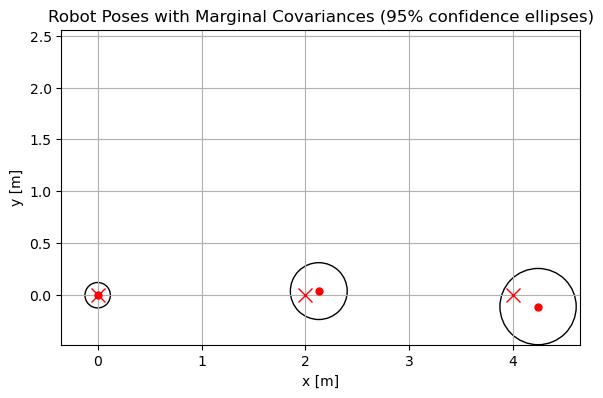

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

for i, pose_key in enumerate(pose_vars, start=1):
    mean = solution.at(pose_key)
    cov = marginals.marginalCovariance(pose_key)
    gtsam_plot.plot_point2_on_axes(ax, point=mean, linespec='r', P=cov)

for i, pose in enumerate(sim_data['ground_truth']['poses']):
    ax.plot(pose[0], pose[1], 'rx', markersize=10, label='GT pose' if i == 0 else "")

ax.set_aspect('equal')
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
xlim =np.array([-0.34940832632868724, 4.645053339153335])
ylim = np.array([-0.4767205818149802, 2.55587773227173])
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_title('Robot Poses with Marginal Covariances (95% confidence ellipses)')
ax.grid(True)
plt.tight_layout()
plt.show()

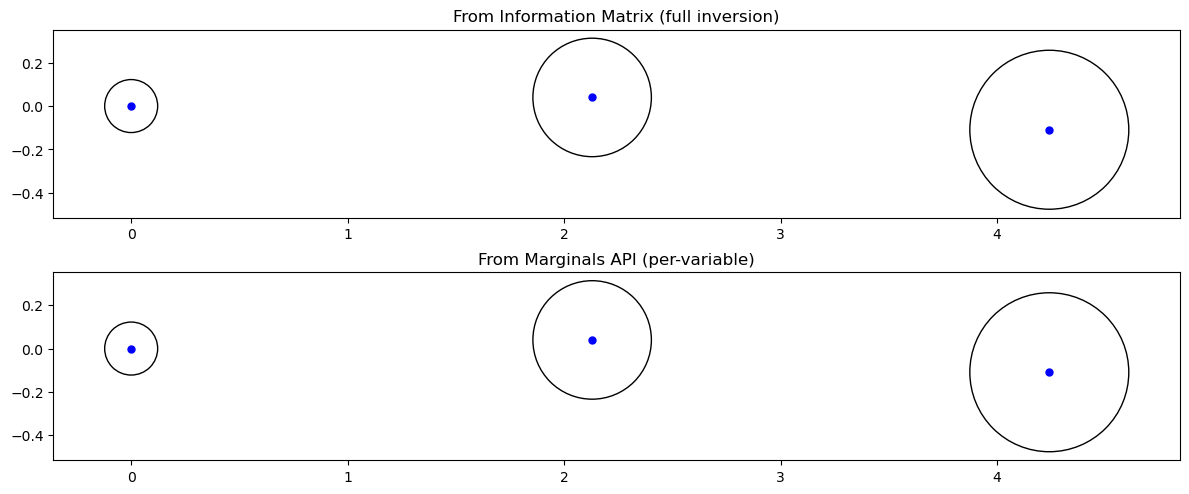

In [18]:
fig, axs = plt.subplots(2, 1, figsize=(12, 5))

for ax, title, cov_source in zip(
    axs,
    ["From Information Matrix (full inversion)", "From Marginals API (per-variable)"],
    ["information", "marginals"]
):

    ax.set_aspect('equal')
    ax.set_title(title)

    for i, pose in enumerate(pose_vars, start=1):
        mean = solution.at(pose)

        if cov_source == "information":
            cov = P_information[2*(i-1):2*i, 2*(i-1):2*i]
        elif cov_source == "marginals":
            cov = marginals.marginalCovariance(pose)

        gtsam_plot.plot_point2_on_axes(ax, point=mean, linespec='b', P=cov)


plt.tight_layout()
plt.show()